# 07: HPPC on Chen2020 (v0.2 disambiguation prep)

## Goal

Apply the same HPPC methodology used on MJ1 (your JES1 paper, CDEFG + bi-exponential τ extraction) to **Chen2020 LG M50 in PyBaMM DFN**, to extract the cell-intrinsic τ_Chen(SOC).

## Why this matters

v0.1 found **48% sign agreement** in Δt(Q80) between simulation and experiment — under MJ1-derived frequency grid (τ_MJ1 = 11.1s). Two non-separable hypotheses remained:

1. **Cell-physics**: SPMe + Chen2020 lacks AC-acceleration mechanism
2. **Frequency-mismatch**: Chen2020 has its own intrinsic τ_Chen ≠ τ_MJ1, so MJ1-derived frequencies don't sample Chen2020's resonance band

This notebook addresses (2) by extracting τ_Chen via the same HPPC method.

## Methodology (matched to MJ1 experimental protocol)

- Charging direction only (matches MJ1 paper)
- Cell pre-conditioning: 1C discharge to V_min, 10 min rest
- For each SOC ∈ {50%, 80%} (Stage 1) → {10, 20, ..., 100%} (Stage 2):
  - 1C CC charge until target Q reached
  - Rest 1800s (long enough for Chen2020 negative particle relaxation: τ_d_neg ≈ 1040s, so 1.7τ_d → ~82% relaxation)
  - 1C discharge pulse 10s
  - Rest 1800s
  - 1C charge pulse 10s
  - Rest 1800s
- Extract τ_Chen via bi-exponential fit on FG-relaxation (60s window, slow branch)

## Model and solver

- **Model**: `pybamm.lithium_ion.DFN(options={"thermal": "lumped"})` (matched to v0.1 thermal config)
- **Parameters**: Chen2020 (LG M50, 5.0 Ah)
- **Solver**: `pybamm.IDAKLUSolver(rtol=1e-6, atol=1e-8)` — DFN-recommended

## Stage 1 today: SOC = {50%, 80%} validation
## Stage 2 (afternoon): full SOC = {10, 20, ..., 100%}

In [1]:
# ============================================================
# Cell 2: Environment + DFN model + Chen2020 parameter validation
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm
from pathlib import Path

print(f"PyBaMM version: {pybamm.__version__}")
print(f"NumPy version: {np.__version__}")

# Build DFN model with lumped thermal (matches v0.1 config)
model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
print(f"\nModel: {model.name}")
print(f"Options: {model.options}")

# Load Chen2020 parameter set
param = pybamm.ParameterValues("Chen2020")

# Quick sanity check on key kinetic / transport parameters
keys_of_interest = [
    "Nominal cell capacity [A.h]",
    "Negative particle radius [m]",
    "Negative particle diffusivity [m2.s-1]",
    "Positive particle radius [m]",
    "Positive particle diffusivity [m2.s-1]",
    "Initial temperature [K]",
    "Ambient temperature [K]",
    "Lower voltage cut-off [V]",
    "Upper voltage cut-off [V]",
]

print("\n=== Chen2020 key parameters (DFN inputs) ===")
for k in keys_of_interest:
    v = param.get(k)
    print(f"  {k}: {v}")

# Compute solid diffusion timescales for reference
R_n = param["Negative particle radius [m]"]
D_n = param["Negative particle diffusivity [m2.s-1]"]
R_p = param["Positive particle radius [m]"]
D_p = param["Positive particle diffusivity [m2.s-1]"]
tau_d_neg = R_n**2 / D_n if not callable(D_n) else None
tau_d_pos = R_p**2 / D_p if not callable(D_p) else None

print(f"\n=== Solid-phase diffusion timescales (R²/D_s) ===")
if tau_d_neg is not None:
    print(f"  τ_d_neg = R_n²/D_n = {tau_d_neg:.1f} s ≈ {tau_d_neg/60:.1f} min")
if tau_d_pos is not None:
    print(f"  τ_d_pos = R_p²/D_p = {tau_d_pos:.1f} s ≈ {tau_d_pos/60:.1f} min")
print(f"\nFor reference: MJ1 experimental τ2_biexp ≈ 11 s (your JES1)")
print(f"Chen2020 negative is ~{tau_d_neg/11:.0f}× slower — frequency-mismatch hypothesis quantified")

# Setup IDAKLU solver
solver = pybamm.IDAKLUSolver(rtol=1e-6, atol=1e-8)
print(f"\nSolver: {solver}")
print(f"  rtol=1e-6, atol=1e-8")

PyBaMM version: 26.3.1
NumPy version: 2.4.4

Model: Doyle-Fuller-Newman model
Options: {'calculate discharge energy': 'false', 'calculate heat source for isothermal models': 'false', 'cell geometry': 'arbitrary', 'contact resistance': 'false', 'convection': 'none', 'current collector': 'uniform', 'diffusivity': 'single', 'dimensionality': 0, 'electrolyte conductivity': 'default', 'exchange-current density': 'single', 'heat of mixing': 'false', 'hydrolysis': 'false', 'intercalation kinetics': 'symmetric Butler-Volmer', 'interface utilisation': 'full', 'lithium plating': 'none', 'lithium plating porosity change': 'false', 'loss of active material': 'none', 'number of MSMR reactions': 'none', 'open-circuit potential': 'single', 'operating mode': 'current', 'particle': 'Fickian diffusion', 'particle mechanics': 'none', 'particle phases': '1', 'particle shape': 'spherical', 'particle size': 'single', 'SEI': 'none', 'SEI film resistance': 'none', 'SEI on cracks': 'false', 'SEI porosity chang

In [9]:
# ============================================================
# Cell 3 (REVISED v3): Single-pulse HPPC for SOC=50% (DISCHARGE direction)
# Following MJ1 real protocol: 1 simulation = 1 SOC × 1 pulse direction
# Rest scaled to Chen2020 timescale: 5000s ≈ 4.8 × τ_d_neg
# Cell-aware: easily switchable between MJ1 (60s rest) and Chen2020 (5000s rest)
# ============================================================

# === Cell-specific timescale parameters ===
CELL_NAME = "Chen2020"   # "MJ1" or "Chen2020"

if CELL_NAME == "MJ1":
    REST_S = 60                    # MJ1 real experimental rest
    NOMINAL_CAPACITY_AH = 3.4
elif CELL_NAME == "Chen2020":
    REST_S = 5000                  # ~4.8 × τ_d_neg for full Chen2020 relaxation
    NOMINAL_CAPACITY_AH = 5.0
else:
    raise ValueError(f"Unknown cell: {CELL_NAME}")

# === Common parameters ===
C_RATE = 1.0
PULSE_DURATION_S = 10
PRECONDITION_REST_S = 600
TARGET_SOC = 50
PULSE_DIRECTION = "discharge"      # "discharge" or "charge"

CUTOFF_CURRENT_DIS_A = NOMINAL_CAPACITY_AH / 136.0
CUTOFF_CURRENT_CHG_A = NOMINAL_CAPACITY_AH / 68.0

charge_time_to_soc_min = (TARGET_SOC / 100.0) / C_RATE * 60.0

print(f"=== Single-pulse HPPC protocol ({CELL_NAME}) ===")
print(f"Target SOC:      {TARGET_SOC}%")
print(f"Pulse direction: {PULSE_DIRECTION}")
print(f"Rest duration:   {REST_S} s")
print(f"  (= {REST_S/1040:.2f} × τ_d_neg for Chen2020,"
      f"  {REST_S/11:.0f} × τ2_biexp_MJ1 for MJ1 reference)")

# Build single-pulse experiment
if PULSE_DIRECTION == "discharge":
    pulse_step = f"Discharge at 1C for {PULSE_DURATION_S} seconds"
else:
    pulse_step = f"Charge at 1C for {PULSE_DURATION_S} seconds"

exp_steps = [
    "Discharge at 1C until 2.5V",
    f"Hold at 2.5V until {CUTOFF_CURRENT_DIS_A*1000:.0f}mA",
    f"Rest for {PRECONDITION_REST_S} seconds",
    f"Charge at 1C for {charge_time_to_soc_min:.2f} minutes",
    f"Rest for {REST_S} seconds",       # pre-HPPC equilibration
    pulse_step,                         # single pulse
    f"Rest for {REST_S} seconds",       # post-pulse FG window
]

experiment = pybamm.Experiment(exp_steps)

print(f"\nExperiment steps ({len(exp_steps)}):")
for i, step in enumerate(exp_steps, 1):
    print(f"  {i}. {step}")

total_real_time_s = (
    60 * 60 +
    20 * 60 +
    PRECONDITION_REST_S +
    charge_time_to_soc_min * 60 +
    2 * REST_S +
    PULSE_DURATION_S
)
print(f"\nEstimated total real-time: {total_real_time_s/60:.1f} min ({total_real_time_s/3600:.2f} hours)")

=== Single-pulse HPPC protocol (Chen2020) ===
Target SOC:      50%
Pulse direction: discharge
Rest duration:   5000 s
  (= 4.81 × τ_d_neg for Chen2020,  455 × τ2_biexp_MJ1 for MJ1 reference)

Experiment steps (7):
  1. Discharge at 1C until 2.5V
  2. Hold at 2.5V until 37mA
  3. Rest for 600 seconds
  4. Charge at 1C for 30.00 minutes
  5. Rest for 5000 seconds
  6. Discharge at 1C for 10 seconds
  7. Rest for 5000 seconds

Estimated total real-time: 286.8 min (4.78 hours)


In [10]:
# ============================================================
# Cell 4: Run the HPPC simulation for SOC=50%
# ============================================================
import time

print(f"Building simulation...")
sim = pybamm.Simulation(
    model=model,
    parameter_values=param,
    experiment=experiment,
    solver=solver,
)

print(f"Solving... (DFN with IDAKLU + CV step, expect 60-180s wall-clock)")
t_start = time.time()
solution = sim.solve()
t_elapsed = time.time() - t_start

print(f"\n✓ Solve complete in {t_elapsed:.1f} s")
print(f"  Number of cycles in solution: {len(solution.cycles)}")
print(f"  Total simulated time: {solution.t[-1]:.1f} s = {solution.t[-1]/60:.1f} min = {solution.t[-1]/3600:.2f} hr")
print(f"  Final voltage: {solution['Voltage [V]'].entries[-1]:.4f} V")
print(f"  Final temperature: {solution['X-averaged cell temperature [K]'].entries[-1] - 273.15:.2f} °C")

# Check each step completed
print(f"\nStep-by-step completion:")
step_names = [
    "1. Dis 1C to 2.5V (CC)",
    "2. Hold 2.5V to 36.8mA (CV)",
    "3. Rest 10 min",
    f"4. Chg 1C 30 min (to SOC={TARGET_SOC}%)",
    "5. Rest 1800s (pre-HPPC)",
    "6. Dis 1C 10s (pulse)",
    "7. Rest 1800s (FG window 1)",
    "8. Chg 1C 10s (pulse)",
    "9. Rest 1800s (FG window 2)",
]

for i, cycle in enumerate(solution.cycles):
    if cycle is None:
        print(f"  {step_names[i] if i < len(step_names) else f'Step {i+1}'}: SKIPPED")
        continue
    t_start_cycle = cycle.t[0]
    t_end_cycle   = cycle.t[-1]
    duration = t_end_cycle - t_start_cycle
    name = step_names[i] if i < len(step_names) else f"Step {i+1}"
    print(f"  {name}: t = [{t_start_cycle:.1f}, {t_end_cycle:.1f}] s  Δt = {duration:.1f} s")

Building simulation...
Solving... (DFN with IDAKLU + CV step, expect 60-180s wall-clock)

✓ Solve complete in 1.2 s
  Number of cycles in solution: 7
  Total simulated time: 16704.8 s = 278.4 min = 4.64 hr
  Final voltage: 3.7344 V
  Final temperature: 25.00 °C

Step-by-step completion:
  1. Dis 1C to 2.5V (CC): t = [0.0, 3562.1] s  Δt = 3562.1 s
  2. Hold 2.5V to 36.8mA (CV): t = [3562.1, 4294.8] s  Δt = 732.7 s
  3. Rest 10 min: t = [4294.8, 4894.8] s  Δt = 600.0 s
  4. Chg 1C 30 min (to SOC=50%): t = [4894.8, 6694.8] s  Δt = 1800.0 s
  5. Rest 1800s (pre-HPPC): t = [6694.8, 11694.8] s  Δt = 5000.0 s
  6. Dis 1C 10s (pulse): t = [11694.8, 11704.8] s  Δt = 10.0 s
  7. Rest 1800s (FG window 1): t = [11704.8, 16704.8] s  Δt = 5000.0 s


In [6]:
# ============================================================
# Cell 5: Sanity check — verify the simulation actually solved physics
# ============================================================

# Get full trajectory
t_all = solution.t                              # full time array (s)
V_all = solution["Voltage [V]"].entries
I_all = solution["Current [A]"].entries
T_all = solution["X-averaged cell temperature [K]"].entries - 273.15  # °C

# Get neg/pos electrode SOC tracking
try:
    SOC_n_avg = solution["X-averaged negative electrode stoichiometry"].entries
    print(f"SOC tracking available (negative electrode stoichiometry)")
except KeyError:
    SOC_n_avg = None
    print(f"SOC tracking variable name differs in this PyBaMM version")

# Step boundaries (from Cell 4 output)
t_step_boundaries = [0, 3562.1, 4294.8, 4894.8, 6694.8, 8494.8, 8504.8, 10304.8, 10314.8, 12114.8]

print(f"\n=== Time-step physical sanity check ===")
print(f"{'Step':<35} {'V [V]':<10} {'I [A]':<10} {'T [°C]':<8}")
print("-" * 65)
for i, t_b in enumerate(t_step_boundaries):
    idx = np.argmin(np.abs(t_all - t_b))
    name = [
        "t=0 (start)",
        "End Step 1 (CC dis to 2.5V)",
        "End Step 2 (CV at 2.5V to 36.8mA)",
        "End Step 3 (10 min rest)",
        "End Step 4 (1C charge 30min to SOC=50%)",
        "End Step 5 (rest 1800s pre-HPPC)",
        "End Step 6 (1C dis pulse 10s)",
        "End Step 7 (rest 1800s, FG window 1)",
        "End Step 8 (1C chg pulse 10s)",
        "End Step 9 (rest 1800s, FG window 2)",
    ][i]
    print(f"{name:<35} {V_all[idx]:<10.4f} {I_all[idx]:<10.4f} {T_all[idx]:<8.3f}")

# Sanity check key invariants
print(f"\n=== Key invariants ===")
print(f"V_min during simulation: {V_all.min():.4f} V (expected ≥ 2.5)")
print(f"V_max during simulation: {V_all.max():.4f} V (expected ≤ 4.2)")
print(f"|I| max: {abs(I_all).max():.3f} A (expected = 5.0 A for 1C)")
print(f"|I| max during pulses: {abs(I_all).max():.3f} A")

# Check rest current magnitude (should be ~0 during rest)
rest_indices = (
    (t_all >= 6694.8) & (t_all <= 8494.8) |    # step 5 rest
    (t_all >= 8504.8) & (t_all <= 10304.8) |   # step 7 rest
    (t_all >= 10314.8) & (t_all <= 12114.8)    # step 9 rest
)
I_rest_max = abs(I_all[rest_indices]).max() if rest_indices.any() else float("nan")
print(f"|I| max during rest periods: {I_rest_max:.6f} A (expected ≈ 0)")

SOC tracking variable name differs in this PyBaMM version

=== Time-step physical sanity check ===
Step                                V [V]      I [A]      T [°C]  
-----------------------------------------------------------------
t=0 (start)                         4.0377     5.0000     25.000  
End Step 1 (CC dis to 2.5V)         2.5000     5.0000     38.810  
End Step 2 (CV at 2.5V to 36.8mA)   2.5023     0.0000     31.060  
End Step 3 (10 min rest)            2.6825     -5.0000    27.878  
End Step 4 (1C charge 30min to SOC=50%) 3.8795     0.0000     37.140  
End Step 5 (rest 1800s pre-HPPC)    3.6233     5.0000     26.305  
End Step 6 (1C dis pulse 10s)       3.7091     0.0000     26.426  
End Step 7 (rest 1800s, FG window 1) 3.8514     -5.0000    25.154  
End Step 8 (1C chg pulse 10s)       3.7637     0.0000     25.295  
End Step 9 (rest 1800s, FG window 2) 3.7370     0.0000     25.032  

=== Key invariants ===
V_min during simulation: 2.5000 V (expected ≥ 2.5)
V_max during simu

In [7]:
# ============================================================
# Cell 5b: Rigorous boundary-aware sanity check
# Use strict open intervals to avoid step-boundary ambiguity
# ============================================================

# Look at the middle of each step (avoid boundaries)
print(f"=== Sampling points 50% INTO each step (avoid boundaries) ===")
print(f"{'Step':<45} {'V [V]':<10} {'I [A]':<10} {'T [°C]':<8}")
print("-" * 75)

step_intervals = [
    ("Step 1: CC dis to 2.5V (sample 50% in)",       1781.0),
    ("Step 2: CV at 2.5V (sample 50% in)",           3928.5),
    ("Step 3: 10 min rest (sample 50% in)",          4594.8),
    ("Step 4: 1C charge to SOC=50% (sample 50% in)", 5794.8),
    ("Step 5: pre-HPPC rest (sample 50% in)",        7594.8),
    ("Step 6: dis pulse 10s (sample 50% in)",        8499.8),
    ("Step 7: FG window 1 (sample 50% in)",          9404.8),
    ("Step 8: chg pulse 10s (sample 50% in)",       10309.8),
    ("Step 9: FG window 2 (sample 50% in)",         11214.8),
]
for name, t_mid in step_intervals:
    idx = np.argmin(np.abs(t_all - t_mid))
    print(f"{name:<45} {V_all[idx]:<10.4f} {I_all[idx]:<10.4f} {T_all[idx]:<8.3f}")

# Strict rest current check (open intervals, exclude boundaries)
print(f"\n=== Rest current strict check (open intervals, 1s buffer from boundaries) ===")
buf = 1.0  # 1 second buffer

rest_masks = {
    "Step 3 (10 min rest)":      (t_all > 4294.8 + buf) & (t_all < 4894.8 - buf),
    "Step 5 (pre-HPPC rest)":    (t_all > 6694.8 + buf) & (t_all < 8494.8 - buf),
    "Step 7 (FG window 1)":      (t_all > 8504.8 + buf) & (t_all < 10304.8 - buf),
    "Step 9 (FG window 2)":      (t_all > 10314.8 + buf) & (t_all < 12114.8 - buf),
}

for name, mask in rest_masks.items():
    if mask.any():
        I_max = abs(I_all[mask]).max()
        n = mask.sum()
        print(f"  {name}: |I|_max = {I_max:.6e} A ({n} points)  {'✓ ≈ 0' if I_max < 1e-3 else '⚠ NON-ZERO'}")

# Pulse current strict check
print(f"\n=== Pulse current strict check (open intervals) ===")
pulse_masks = {
    "Step 6 (dis pulse 10s)": (t_all > 8494.8 + 0.1) & (t_all < 8504.8 - 0.1),
    "Step 8 (chg pulse 10s)": (t_all > 10304.8 + 0.1) & (t_all < 10314.8 - 0.1),
}
for name, mask in pulse_masks.items():
    if mask.any():
        I_mean = I_all[mask].mean()
        I_max = abs(I_all[mask]).max()
        n = mask.sum()
        print(f"  {name}: I_mean = {I_mean:+.4f} A, |I|_max = {I_max:.4f} A ({n} points)")

# SOC end-of-charge cross-check via Q integration (the gold standard)
from scipy.integrate import cumulative_trapezoid
# In PyBaMM: I > 0 is discharge, so Q_charged = -∫I dt
Q_total_C = -cumulative_trapezoid(I_all, t_all, initial=0)  # Coulombs
Q_total_Ah = Q_total_C / 3600.0

# At end of step 4 (charge to SOC=50%), Q should be -Q_dis_max + 2.5 Ah ≈ ?
idx_end_step4 = np.argmin(np.abs(t_all - 6694.8))
idx_end_step1 = np.argmin(np.abs(t_all - 3562.1))  # end of CC discharge
idx_end_step2 = np.argmin(np.abs(t_all - 4294.8))  # end of CV (true SOC=0)

Q_dis = Q_total_Ah[idx_end_step1] - Q_total_Ah[0]      # negative (discharged)
Q_dis_total = Q_total_Ah[idx_end_step2] - Q_total_Ah[0]  # CC + CV
Q_chg_to_50 = Q_total_Ah[idx_end_step4] - Q_total_Ah[idx_end_step2]

print(f"\n=== Charge accounting (gold-standard SOC verification) ===")
print(f"  Q discharged in CC step:        {Q_dis:.3f} Ah")
print(f"  Q discharged total (CC+CV):     {Q_dis_total:.3f} Ah  (should be near -5 Ah for full discharge)")
print(f"  Q charged in step 4 (to SOC50%): {Q_chg_to_50:+.3f} Ah  (should be +2.5 Ah for SOC=50%)")
print(f"  Implied SOC at end of step 4:    {(Q_chg_to_50 / 5.0) * 100:.1f}%  (target = 50%)")

=== Sampling points 50% INTO each step (avoid boundaries) ===
Step                                          V [V]      I [A]      T [°C]  
---------------------------------------------------------------------------
Step 1: CC dis to 2.5V (sample 50% in)        3.5375     5.0000     35.904  
Step 2: CV at 2.5V (sample 50% in)            2.5000     0.2934     34.568  
Step 3: 10 min rest (sample 50% in)           2.5101     0.0000     29.131  
Step 4: 1C charge to SOC=50% (sample 50% in)  3.7384     -5.0000    35.918  
Step 5: pre-HPPC rest (sample 50% in)         3.7414     0.0000     28.967  
Step 6: dis pulse 10s (sample 50% in)         3.6077     5.0000     26.367  
Step 7: FG window 1 (sample 50% in)           3.7343     0.0000     25.474  
Step 8: chg pulse 10s (sample 50% in)         3.8686     -5.0000    25.221  
Step 9: FG window 2 (sample 50% in)           3.7371     0.0000     25.096  

=== Rest current strict check (open intervals, 1s buffer from boundaries) ===
  Step 3 (10 

=== Step boundaries from solution.cycles ===
  Step 1: [0.0, 3562.1] s  Δt = 3562.1 s
  Step 2: [3562.1, 4294.8] s  Δt = 732.7 s
  Step 3: [4294.8, 4894.8] s  Δt = 600.0 s
  Step 4: [4894.8, 6694.8] s  Δt = 1800.0 s
  Step 5: [6694.8, 11694.8] s  Δt = 5000.0 s
  Step 6: [11694.8, 11704.8] s  Δt = 10.0 s
  Step 7: [11704.8, 16704.8] s  Δt = 5000.0 s

HPPC extraction window: [6694.8, 16704.8] s
HPPC duration: 10010.0 s = 166.8 min

HPPC segment: 404 samples
  Time range: 0 to 10010.0 s = 166.8 min
  V range: 3.5942 to 3.8795 V
  I range PyBaMM: +0.0000 to +5.0000 A
  I range DAS60:  -5.0000 to -0.0000 A
    → discharge pulse (PyBaMM +5A) becomes -5A in DAS60 convention ✓

DataFrame shape: (404, 3)

=== Pulse count verification ===
Discharge pulse samples (I<-1A): 51
Charge pulse samples (I>+1A):    0
✓ Exactly one discharge pulse — single-pulse protocol confirmed


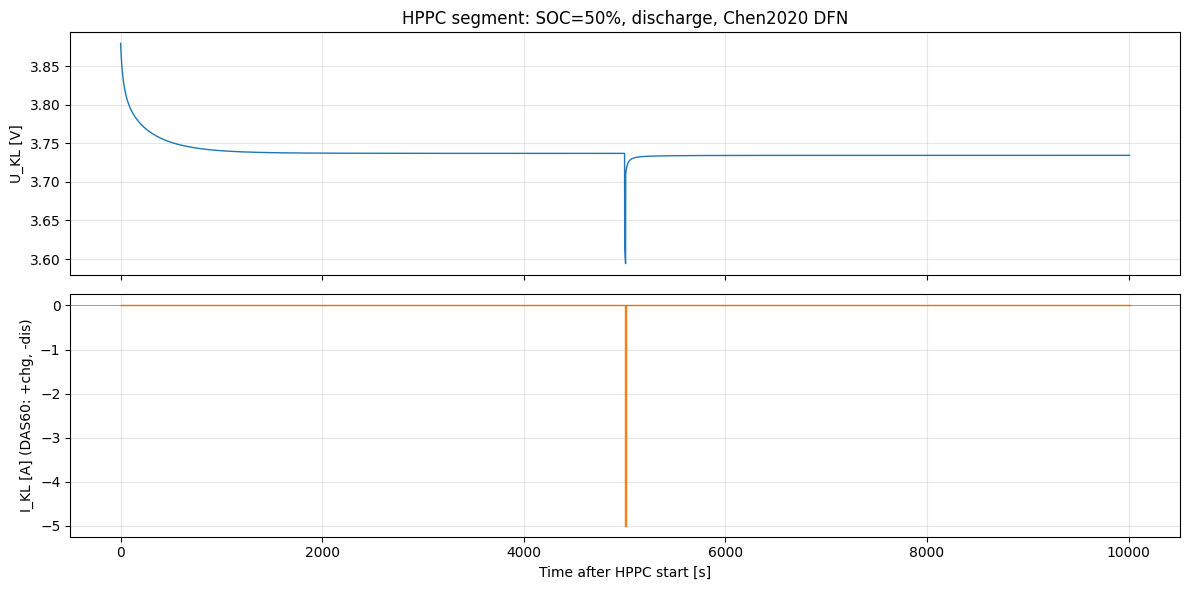


Saved: ../figures/07_hppc_chen2020_SOC50_signal.png


In [17]:
# ============================================================
# Cell 6 (REVISED v2): Extract HPPC segment from solution dynamically
# Auto-detect step boundaries from solution.cycles instead of hardcoding
# ============================================================

# Auto-detect step boundaries from solution
print("=== Step boundaries from solution.cycles ===")
step_boundaries = []
for i, cycle in enumerate(solution.cycles):
    t_start_cycle = float(cycle.t[0])
    t_end_cycle = float(cycle.t[-1])
    step_boundaries.append((t_start_cycle, t_end_cycle))
    print(f"  Step {i+1}: [{t_start_cycle:.1f}, {t_end_cycle:.1f}] s  Δt = {t_end_cycle-t_start_cycle:.1f} s")

# Single-pulse HPPC: extract from end of step 4 (charge to SOC) to end of step 7 (post-pulse rest)
# Step indices (0-based): 0=CC dis, 1=CV, 2=10min rest, 3=CC charge to SOC, 4=pre-HPPC rest, 5=pulse, 6=post-pulse rest
T_HPPC_START_S = step_boundaries[4][0]   # start of step 5 (pre-HPPC rest)
T_HPPC_END_S   = step_boundaries[6][1]   # end of step 7 (post-pulse rest)

print(f"\nHPPC extraction window: [{T_HPPC_START_S:.1f}, {T_HPPC_END_S:.1f}] s")
print(f"HPPC duration: {T_HPPC_END_S - T_HPPC_START_S:.1f} s = {(T_HPPC_END_S - T_HPPC_START_S)/60:.1f} min")

# Re-extract trajectory (in case Cell 4 was rerun and t_all/V_all/I_all need refresh)
t_all = solution.t
V_all = solution["Voltage [V]"].entries
I_all = solution["Current [A]"].entries

# Mask trajectory for HPPC region
# Use strict-greater-than at start to exclude step 4 boundary contamination
# Strict-greater excludes step 4 boundary contamination (PyBaMM has duplicate timestamps at step transitions)
EPS = 1e-3  # 1 ms buffer
mask_hppc = (t_all > T_HPPC_START_S + EPS) & (t_all <= T_HPPC_END_S)
t_hppc_s = t_all[mask_hppc] - T_HPPC_START_S
V_hppc = V_all[mask_hppc]
I_hppc = I_all[mask_hppc]

print(f"\nHPPC segment: {mask_hppc.sum()} samples")
print(f"  Time range: 0 to {t_hppc_s[-1]:.1f} s = {t_hppc_s[-1]/60:.1f} min")
print(f"  V range: {V_hppc.min():.4f} to {V_hppc.max():.4f} V")
print(f"  I range PyBaMM: {I_hppc.min():+.4f} to {I_hppc.max():+.4f} A")

# Sign convention: PyBaMM I>0=dis → DAS60 I<0=dis. Flip sign.
I_hppc_dasconv = -I_hppc
print(f"  I range DAS60:  {I_hppc_dasconv.min():+.4f} to {I_hppc_dasconv.max():+.4f} A")
print(f"    → discharge pulse (PyBaMM +5A) becomes -5A in DAS60 convention ✓")

# Build DataFrame in DAS60 schema
df_hppc = pd.DataFrame({
    "Time": t_hppc_s * 1000.0,
    "U_KL[V]": V_hppc,
    "I_KL[A]": I_hppc_dasconv,
})
df_hppc.attrs["soc_from_header"] = TARGET_SOC

print(f"\nDataFrame shape: {df_hppc.shape}")

# Verify exactly ONE pulse (single-pulse protocol)
neg_pulse_count = (df_hppc["I_KL[A]"] < -1.0).sum()
pos_pulse_count = (df_hppc["I_KL[A]"] > +1.0).sum()
print(f"\n=== Pulse count verification ===")
print(f"Discharge pulse samples (I<-1A): {neg_pulse_count}")
print(f"Charge pulse samples (I>+1A):    {pos_pulse_count}")
if neg_pulse_count > 0 and pos_pulse_count == 0:
    print("✓ Exactly one discharge pulse — single-pulse protocol confirmed")
elif neg_pulse_count == 0 and pos_pulse_count > 0:
    print("✓ Exactly one charge pulse — single-pulse protocol confirmed")
else:
    print(f"⚠ Multiple pulses or none detected — check protocol")

# Plot V(t) and I(t)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(t_hppc_s, V_hppc, linewidth=1.0, color='C0')
ax1.set_ylabel("U_KL [V]")
ax1.grid(True, alpha=0.3)
ax1.set_title(f"HPPC segment: SOC={TARGET_SOC}%, {PULSE_DIRECTION}, Chen2020 DFN")

ax2.plot(t_hppc_s, I_hppc_dasconv, linewidth=1.0, color='C1')
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_ylabel("I_KL [A] (DAS60: +chg, -dis)")
ax2.set_xlabel("Time after HPPC start [s]")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/07_hppc_chen2020_SOC50_signal.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved: ../figures/07_hppc_chen2020_SOC50_signal.png")

In [15]:
# ============================================================
# Cell 7: Import HPPC fitting module + extract τ_Chen for SOC=50% discharge
# ============================================================
import sys
sys.path.insert(0, "..")  # so we can import from scripts/

from scripts.hppc_descriptor_pybamm import extract_hppc_descriptors, CELL_CONFIGS

print("Cell config for Chen2020:")
for k, v in CELL_CONFIGS["Chen2020"].items():
    print(f"  {k}: {v}")

# Extract descriptors for the SOC=50% discharge HPPC trace built in Cell 6
print(f"\nRunning fit on df_hppc (SOC={TARGET_SOC}%, direction={PULSE_DIRECTION})...")
row = extract_hppc_descriptors(
    df=df_hppc,
    cell_config=CELL_CONFIGS["Chen2020"],
    soc=TARGET_SOC,
    pulse_direction=PULSE_DIRECTION,
)

# Pretty-print critical fields
print(f"\n=== HPPC descriptor row (Chen2020 DFN, SOC={TARGET_SOC}% {PULSE_DIRECTION}) ===")
print(f"\n--- Time constants ---")
print(f"  tau1_primary    (5000s window): {row['tau1_primary']:.3f} s")
print(f"  tau2_biexp      (5000s window): {row['tau2_biexp']:.3f} s   ← τ_Chen primary")
print(f"  tau1_secondary  (60s window):   {row['tau1_secondary_60s']:.3f} s")
print(f"  tau2_secondary  (60s window):   {row['tau2_secondary_60s']:.3f} s   ← MJ1-comparable")
print(f"  tau_FG_eff      (5000s, 63.2%): {row['tau_FG_eff']:.3f} s")
print(f"  tau_tail        (1500-5000s):   {row['tau_tail']:.3f} s")
print(f"  t95 (95% recovery):             {row['t95']:.3f} s")
print(f"  t99 (99% recovery):             {row['t99']:.3f} s")

print(f"\n--- Resistance ---")
print(f"  R0 = {row['R0']*1000:.2f} mΩ")
print(f"  R0_CD = {row['R0_CD']*1000:.2f} mΩ, R0_EF = {row['R0_EF']*1000:.2f} mΩ")

print(f"\n--- Fit quality ---")
print(f"  R² primary (5000s): {row['fit_R2_primary']:.6f}")
print(f"  R² secondary (60s): {row['fit_R2_60s']:.6f}")
print(f"  R² tail:            {row['tail_R2']:.6f}")

print(f"\n--- Voltage points ---")
print(f"  Uinf (5000s baseline): {row['Uinf']:.4f} V")
print(f"  C={row['Uc']:.4f}, D={row['Ud']:.4f}, E={row['Ue']:.4f}, F={row['Uf']:.4f}, G={row['Ug']:.4f}")

print(f"\n--- Pulse points ---")
print(f"  ton = {row['ton_ms']:.0f} ms, toff = {row['toff_ms']:.0f} ms")
print(f"  I0 = {row['I0']:.4f} A, Ip = {row['Ip']:.4f} A")

# Compare to MJ1 ballpark for sanity
print(f"\n=== Cross-cell comparison (sanity) ===")
print(f"MJ1 reference (your CSV, SOC=52.2 discharge):")
print(f"  tau2_biexp (60s window) ≈ 15.58 s")
print(f"")
print(f"Chen2020 simulation (this run):")
print(f"  tau2_biexp ({row['primary_window_s']:.0f}s window):  {row['tau2_biexp']:.2f} s")
print(f"  tau2_secondary_60s (60s window):  {row['tau2_secondary_60s']:.2f} s   ← direct comparison to MJ1")
print(f"")
print(f"Frequency-mismatch hypothesis check:")
print(f"  ratio (Chen/MJ1) at primary window:    {row['tau2_biexp'] / 15.58:.1f}×")
print(f"  ratio (Chen/MJ1) at common 60s window: {row['tau2_secondary_60s'] / 15.58:.1f}×")

Cell config for Chen2020:
  descriptor_windows_s: [60.0, 5000.0]
  primary_tau2_window_s: 5000.0
  tau_fg_eff_window_s: 5000.0
  tail_fit_start_s: 1500.0
  tail_fit_end_s: 5000.0
  uinf_window_start_s: 4500.0
  uinf_window_end_s: 5000.0
  name: Chen2020

Running fit on df_hppc (SOC=50%, direction=discharge)...

=== HPPC descriptor row (Chen2020 DFN, SOC=50% discharge) ===

--- Time constants ---
  tau1_primary    (5000s window): 58.315 s
  tau2_biexp      (5000s window): 1000000.000 s   ← τ_Chen primary
  tau1_secondary  (60s window):   6.843 s
  tau2_secondary  (60s window):   43.541 s   ← MJ1-comparable
  tau_FG_eff      (5000s, 63.2%): 122.560 s
  tau_tail        (1500-5000s):   999999.644 s
  t95 (95% recovery):             765.640 s
  t99 (99% recovery):             1348.700 s

--- Resistance ---
  R0 = 10.26 mΩ
  R0_CD = 20.49 mΩ, R0_EF = 0.04 mΩ

--- Fit quality ---
  R² primary (5000s): 0.925420
  R² secondary (60s): 0.999995
  R² tail:            0.539979

--- Voltage points -

In [18]:
# ============================================================
# Cell 7: Import HPPC fitting module + extract τ_Chen for SOC=50% discharge
# ============================================================
import importlib
import scripts.hppc_descriptor_pybamm
importlib.reload(scripts.hppc_descriptor_pybamm)
from scripts.hppc_descriptor_pybamm import extract_hppc_descriptors, CELL_CONFIGS

print("Cell config for Chen2020 (after module reload):")
for k, v in CELL_CONFIGS["Chen2020"].items():
    print(f"  {k}: {v}")

# Extract descriptors
print(f"\nRunning fit on df_hppc (SOC={TARGET_SOC}%, direction={PULSE_DIRECTION})...")
row = extract_hppc_descriptors(
    df=df_hppc,
    cell_config=CELL_CONFIGS["Chen2020"],
    soc=TARGET_SOC,
    pulse_direction=PULSE_DIRECTION,
)

print(f"\n=== HPPC descriptor row (Chen2020 DFN, SOC={TARGET_SOC}% {PULSE_DIRECTION}) ===")
print(f"\n--- Time constants ---")
print(f"  tau1_primary    (1000s window): {row['tau1_primary']:.3f} s")
print(f"  tau2_biexp      (1000s window): {row['tau2_biexp']:.3f} s   ← τ_Chen primary")
print(f"  tau1_secondary  (60s window):   {row['tau1_secondary_60s']:.3f} s")
print(f"  tau2_secondary  (60s window):   {row['tau2_secondary_60s']:.3f} s   ← MJ1-comparable")
print(f"  tau_FG_eff      (1000s, 63.2%): {row['tau_FG_eff']:.3f} s")
print(f"  tau_tail        (300-1000s):    {row['tau_tail']:.3f} s")
print(f"  t95 (95% recovery):             {row['t95']:.3f} s")
print(f"  t99 (99% recovery):             {row['t99']:.3f} s")

print(f"\n--- Resistance ---")
print(f"  R0 = {row['R0']*1000:.2f} mΩ")
print(f"  R0_CD = {row['R0_CD']*1000:.2f} mΩ, R0_EF = {row['R0_EF']*1000:.2f} mΩ")

print(f"\n--- Fit quality ---")
print(f"  R² primary (1000s): {row['fit_R2_primary']:.6f}")
print(f"  R² secondary (60s): {row['fit_R2_60s']:.6f}")
print(f"  R² tail:            {row['tail_R2']:.6f}")

print(f"\n--- Voltage points ---")
print(f"  Uinf (1000s baseline): {row['Uinf']:.4f} V")
print(f"  C={row['Uc']:.4f}, D={row['Ud']:.4f}, E={row['Ue']:.4f}, F={row['Uf']:.4f}, G={row['Ug']:.4f}")

print(f"\n--- Pulse points ---")
print(f"  ton = {row['ton_ms']:.0f} ms = {row['ton_ms']/1000:.1f} s")
print(f"  toff = {row['toff_ms']:.0f} ms = {row['toff_ms']/1000:.1f} s")
print(f"  I0 = {row['I0']:.4f} A, Ip = {row['Ip']:.4f} A")

print(f"\n=== Cross-cell comparison (sanity) ===")
print(f"MJ1 reference (CSV, SOC=52.2 discharge, 60s window):  tau2_biexp ≈ 15.58 s")
print(f"")
print(f"Chen2020 simulation (SOC=50% discharge):")
print(f"  tau2_biexp (1000s window): {row['tau2_biexp']:.2f} s   ← TRUE τ_Chen, full slow branch")
print(f"  tau2_secondary_60s (60s):  {row['tau2_secondary_60s']:.2f} s   ← apples-to-apples vs MJ1")
print(f"")
print(f"Frequency-mismatch hypothesis:")
print(f"  Chen/MJ1 at primary (1000s vs 60s):    {row['tau2_biexp']/15.58:.1f}×")
print(f"  Chen/MJ1 at common 60s window:         {row['tau2_secondary_60s']/15.58:.1f}×")
print(f"  Physics expectation: ~10× (tau_macro_neg / tau_MJ1 = 105/11)")

Cell config for Chen2020 (after module reload):
  descriptor_windows_s: [60.0, 1000.0]
  primary_tau2_window_s: 1000.0
  tau_fg_eff_window_s: 1000.0
  tail_fit_start_s: 300.0
  tail_fit_end_s: 1000.0
  uinf_window_start_s: 800.0
  uinf_window_end_s: 1000.0
  name: Chen2020

Running fit on df_hppc (SOC=50%, direction=discharge)...

=== HPPC descriptor row (Chen2020 DFN, SOC=50% discharge) ===

--- Time constants ---
  tau1_primary    (1000s window): 11.546 s
  tau2_biexp      (1000s window): 63.597 s   ← τ_Chen primary
  tau1_secondary  (60s window):   5.946 s
  tau2_secondary  (60s window):   27.830 s   ← MJ1-comparable
  tau_FG_eff      (1000s, 63.2%): 26.868 s
  tau_tail        (300-1000s):    266.155 s
  t95 (95% recovery):             193.574 s
  t99 (99% recovery):             552.083 s

--- Resistance ---
  R0 = 23.05 mΩ
  R0_CD = 23.43 mΩ, R0_EF = 22.68 mΩ

--- Fit quality ---
  R² primary (1000s): 0.999630
  R² secondary (60s): 0.999995
  R² tail:            0.999754

--- Volta

In [20]:
# ============================================================
# Cell 8: Batch HPPC runner — small-scale validation (4 cases)
# Sweep SOC × pulse_direction, collect descriptor rows into DataFrame
# ============================================================
import time

# Module reload guard (in case Cell 7 wasn't run)
import importlib
import scripts.hppc_descriptor_pybamm
importlib.reload(scripts.hppc_descriptor_pybamm)
from scripts.hppc_descriptor_pybamm import extract_hppc_descriptors, CELL_CONFIGS


def run_single_hppc(target_soc, pulse_direction, cell_name="Chen2020", verbose=True):
    """
    Run a single PyBaMM HPPC simulation + extract descriptors.
    
    Returns
    -------
    dict
        Descriptor row with metadata (target_soc, pulse_direction, wall_clock_s, status)
        plus all τ/R0/fit_R2/etc fields from extract_hppc_descriptors.
    """
    # === Build experiment (same protocol as Cell 3 v3) ===
    NOMINAL_CAPACITY_AH = 5.0
    C_RATE = 1.0
    PULSE_DURATION_S = 10
    REST_S = 5000
    PRECONDITION_REST_S = 600
    
    CUTOFF_CURRENT_DIS_A = NOMINAL_CAPACITY_AH / 136.0
    charge_time_to_soc_min = (target_soc / 100.0) / C_RATE * 60.0
    
    if pulse_direction == "discharge":
        pulse_step = f"Discharge at 1C for {PULSE_DURATION_S} seconds"
    elif pulse_direction == "charge":
        pulse_step = f"Charge at 1C for {PULSE_DURATION_S} seconds"
    else:
        raise ValueError(f"Unknown direction: {pulse_direction}")
    
    exp_steps = [
        "Discharge at 1C until 2.5V",
        f"Hold at 2.5V until {CUTOFF_CURRENT_DIS_A*1000:.0f}mA",
        f"Rest for {PRECONDITION_REST_S} seconds",
        f"Charge at 1C for {charge_time_to_soc_min:.2f} minutes",
        f"Rest for {REST_S} seconds",
        pulse_step,
        f"Rest for {REST_S} seconds",
    ]
    experiment = pybamm.Experiment(exp_steps)
    
    # === Run simulation ===
    sim = pybamm.Simulation(
        model=model,
        parameter_values=param,
        experiment=experiment,
        solver=solver,
    )
    
    t_start = time.time()
    try:
        sol = sim.solve()
        wall_clock_s = time.time() - t_start
        sim_status = "ok"
    except Exception as e:
        wall_clock_s = time.time() - t_start
        if verbose:
            print(f"  ✗ SOC={target_soc}% {pulse_direction}: SIM FAILED — {e}")
        return {
            "target_soc": target_soc, "pulse_direction": pulse_direction,
            "wall_clock_s": wall_clock_s, "status": f"sim_fail: {e}",
            "tau2_secondary_60s": np.nan, "tau2_biexp": np.nan, "R0": np.nan,
        }
    
    # === Extract HPPC segment ===
    step_b = [(float(c.t[0]), float(c.t[-1])) for c in sol.cycles]
    T_HPPC_START_S = step_b[4][0]
    T_HPPC_END_S = step_b[6][1]
    
    t_all_l = sol.t
    V_all_l = sol["Voltage [V]"].entries
    I_all_l = sol["Current [A]"].entries
    
    EPS = 1e-3
    mask = (t_all_l > T_HPPC_START_S + EPS) & (t_all_l <= T_HPPC_END_S)
    t_seg = t_all_l[mask] - T_HPPC_START_S
    V_seg = V_all_l[mask]
    I_seg_dasconv = -I_all_l[mask]   # PyBaMM → DAS60 sign flip
    
    df_local = pd.DataFrame({
        "Time": t_seg * 1000.0,
        "U_KL[V]": V_seg,
        "I_KL[A]": I_seg_dasconv,
    })
    
    # === Extract descriptors ===
    try:
        row = extract_hppc_descriptors(
            df=df_local,
            cell_config=CELL_CONFIGS[cell_name],
            soc=target_soc,
            pulse_direction=pulse_direction,
        )
        row["target_soc"] = target_soc
        row["pulse_direction"] = pulse_direction
        row["wall_clock_s"] = wall_clock_s
        row["status"] = "ok"
        if verbose:
            tau60 = row.get("tau2_secondary_60s", np.nan)
            tau1k = row.get("tau2_biexp", np.nan)
            R0 = row.get("R0", np.nan)
            print(f"  ✓ SOC={target_soc:3d}% {pulse_direction:9s}: "
                  f"τ2_60s={tau60:6.2f}s, τ2_1000s={tau1k:7.2f}s, R0={R0*1000:.1f}mΩ "
                  f"({wall_clock_s:.1f}s)")
        return row
    except Exception as e:
        if verbose:
            print(f"  ✗ SOC={target_soc}% {pulse_direction}: FIT FAILED — {e}")
        return {
            "target_soc": target_soc, "pulse_direction": pulse_direction,
            "wall_clock_s": wall_clock_s, "status": f"fit_fail: {e}",
            "tau2_secondary_60s": np.nan, "tau2_biexp": np.nan, "R0": np.nan,
        }


# === Stage 1 small-scale: SOC=[50, 80] × [discharge, charge] ===
print("=" * 70)
print("Stage 1: Small-scale validation — 4 cases")
print("=" * 70)

stage1_cases = [
    (50, "discharge"),
    (50, "charge"),
    (80, "discharge"),
    (80, "charge"),
]

stage1_results = []
batch_t_start = time.time()
for soc, direction in stage1_cases:
    r = run_single_hppc(soc, direction, "Chen2020")
    stage1_results.append(r)

batch_total = time.time() - batch_t_start
print(f"\nStage 1 batch wall-clock: {batch_total:.1f} s for 4 cases ({batch_total/4:.1f} s/case)")

# === Build DataFrame ===
df_stage1 = pd.DataFrame(stage1_results)

# Reorder key columns to front
front_cols = ["target_soc", "pulse_direction", "status",
              "tau2_secondary_60s", "fit_R2_60s",                # ← 加 R²
              "tau2_biexp", "fit_R2_primary", "fit_RMSE_primary", # ← 加 R² + RMSE
              "tau1_secondary_60s", "tau1_primary",
              "tau_tail", "tau_FG_eff",
              "R0", "wall_clock_s"]
front_cols = [c for c in front_cols if c in df_stage1.columns]
other_cols = [c for c in df_stage1.columns if c not in front_cols]
df_stage1 = df_stage1[front_cols + other_cols]

print(f"\n=== Stage 1 results ===")
print(df_stage1[front_cols[:9]].to_string(index=False))

Stage 1: Small-scale validation — 4 cases
  ✓ SOC= 50% discharge: τ2_60s= 27.83s, τ2_1000s=  63.60s, R0=23.1mΩ (1.2s)
  ✓ SOC= 50% charge   : τ2_60s= 26.46s, τ2_1000s=  61.94s, R0=23.5mΩ (1.0s)
  ✓ SOC= 80% discharge: τ2_60s= 27.31s, τ2_1000s=  64.47s, R0=24.4mΩ (1.5s)
  ✓ SOC= 80% charge   : τ2_60s= 27.03s, τ2_1000s=  61.03s, R0=25.0mΩ (1.0s)

Stage 1 batch wall-clock: 4.9 s for 4 cases (1.2 s/case)

=== Stage 1 results ===
 target_soc pulse_direction status  tau2_secondary_60s  fit_R2_60s  tau2_biexp  fit_R2_primary  fit_RMSE_primary  tau1_secondary_60s
         50       discharge     ok           27.830123    0.999995   63.597347        0.999630          0.000183            5.945985
         50          charge     ok           26.463016    0.999993   61.943364        0.999631          0.000195            5.600981
         80       discharge     ok           27.314497    0.999992   64.474730        0.999581          0.000206            5.578594
         80          charge     ok     

In [21]:
# ============================================================
# Cell 9: Stage 2 — Full SOC sweep (10 SOC × 2 directions = 20 cases)
# Reuses run_single_hppc() defined in Cell 8
# Robust: failed cases logged but don't block the batch
# ============================================================
import time

# Module reload guard
import importlib
import scripts.hppc_descriptor_pybamm
importlib.reload(scripts.hppc_descriptor_pybamm)
from scripts.hppc_descriptor_pybamm import extract_hppc_descriptors, CELL_CONFIGS

# === Full SOC grid ===
SOC_GRID = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
DIRECTIONS = ["discharge", "charge"]

stage2_cases = [(soc, d) for soc in SOC_GRID for d in DIRECTIONS]
print(f"Stage 2: {len(stage2_cases)} total cases ({len(SOC_GRID)} SOC × {len(DIRECTIONS)} directions)")

print("\n" + "=" * 70)
print(f"Running Stage 2 batch (Chen2020 DFN + IDAKLU)")
print("=" * 70)

stage2_results = []
batch_t_start = time.time()
n_ok = 0
n_fail = 0

for i, (soc, direction) in enumerate(stage2_cases, 1):
    print(f"[{i:2d}/{len(stage2_cases)}] ", end="")
    r = run_single_hppc(soc, direction, "Chen2020", verbose=True)
    stage2_results.append(r)
    if r.get("status") == "ok":
        n_ok += 1
    else:
        n_fail += 1

batch_total = time.time() - batch_t_start

print(f"\n" + "=" * 70)
print(f"Stage 2 complete: {n_ok}/{len(stage2_cases)} OK, {n_fail} failed")
print(f"Total batch wall-clock: {batch_total:.1f} s ({batch_total/len(stage2_cases):.1f} s/case)")
print("=" * 70)

# === Build the Stage 2 DataFrame ===
df_stage2 = pd.DataFrame(stage2_results)

# Reorder columns
front_cols = ["target_soc", "pulse_direction", "status",
              "tau2_secondary_60s", "fit_R2_60s",
              "tau2_biexp", "fit_R2_primary", "fit_RMSE_primary",
              "tau1_secondary_60s", "tau1_primary",
              "tau_tail", "tail_R2", "tau_FG_eff",
              "R0", "R0_CD", "R0_EF",
              "Uinf", "Uf",
              "wall_clock_s"]
front_cols = [c for c in front_cols if c in df_stage2.columns]
other_cols = [c for c in df_stage2.columns if c not in front_cols]
df_stage2 = df_stage2[front_cols + other_cols]

# === Display Stage 2 summary table ===
display_cols = ["target_soc", "pulse_direction", "status",
                "tau2_secondary_60s", "fit_R2_60s",
                "tau2_biexp", "fit_R2_primary",
                "tau_tail", "R0"]

print("\n=== Stage 2 results (key columns) ===")
with pd.option_context('display.float_format', '{:.4f}'.format,
                        'display.width', 200,
                        'display.max_columns', 20):
    print(df_stage2[display_cols].to_string(index=False))

# === Save full stage2 results (for later analysis) ===
out_csv = "../data/results_day8_stage2_hppc_chen2020.csv"
df_stage2.to_csv(out_csv, index=False)
print(f"\nSaved full results to: {out_csv}")

Stage 2: 20 total cases (10 SOC × 2 directions)

Running Stage 2 batch (Chen2020 DFN + IDAKLU)
[ 1/20]   ✓ SOC= 10% discharge: τ2_60s= 20.62s, τ2_1000s=  35.65s, R0=28.3mΩ (1.2s)
[ 2/20]   ✓ SOC= 10% charge   : τ2_60s= 19.72s, τ2_1000s=  33.27s, R0=28.2mΩ (1.2s)
[ 3/20]   ✓ SOC= 20% discharge: τ2_60s= 24.44s, τ2_1000s=  41.54s, R0=25.6mΩ (1.1s)
[ 4/20]   ✓ SOC= 20% charge   : τ2_60s= 23.83s, τ2_1000s=  42.10s, R0=25.8mΩ (1.0s)
[ 5/20]   ✓ SOC= 30% discharge: τ2_60s= 23.29s, τ2_1000s=  40.05s, R0=24.2mΩ (1.3s)
[ 6/20]   ✓ SOC= 30% charge   : τ2_60s= 23.02s, τ2_1000s=  40.83s, R0=24.6mΩ (1.0s)
[ 7/20]   ✓ SOC= 40% discharge: τ2_60s= 26.08s, τ2_1000s=  51.64s, R0=23.4mΩ (1.1s)
[ 8/20]   ✓ SOC= 40% charge   : τ2_60s= 25.09s, τ2_1000s=  48.61s, R0=23.9mΩ (1.1s)
[ 9/20]   ✓ SOC= 50% discharge: τ2_60s= 27.83s, τ2_1000s=  63.60s, R0=23.1mΩ (1.2s)
[10/20]   ✓ SOC= 50% charge   : τ2_60s= 26.46s, τ2_1000s=  61.94s, R0=23.5mΩ (1.0s)
[11/20]   ✓ SOC= 60% discharge: τ2_60s= 27.12s, τ2_1000s=  54.27s

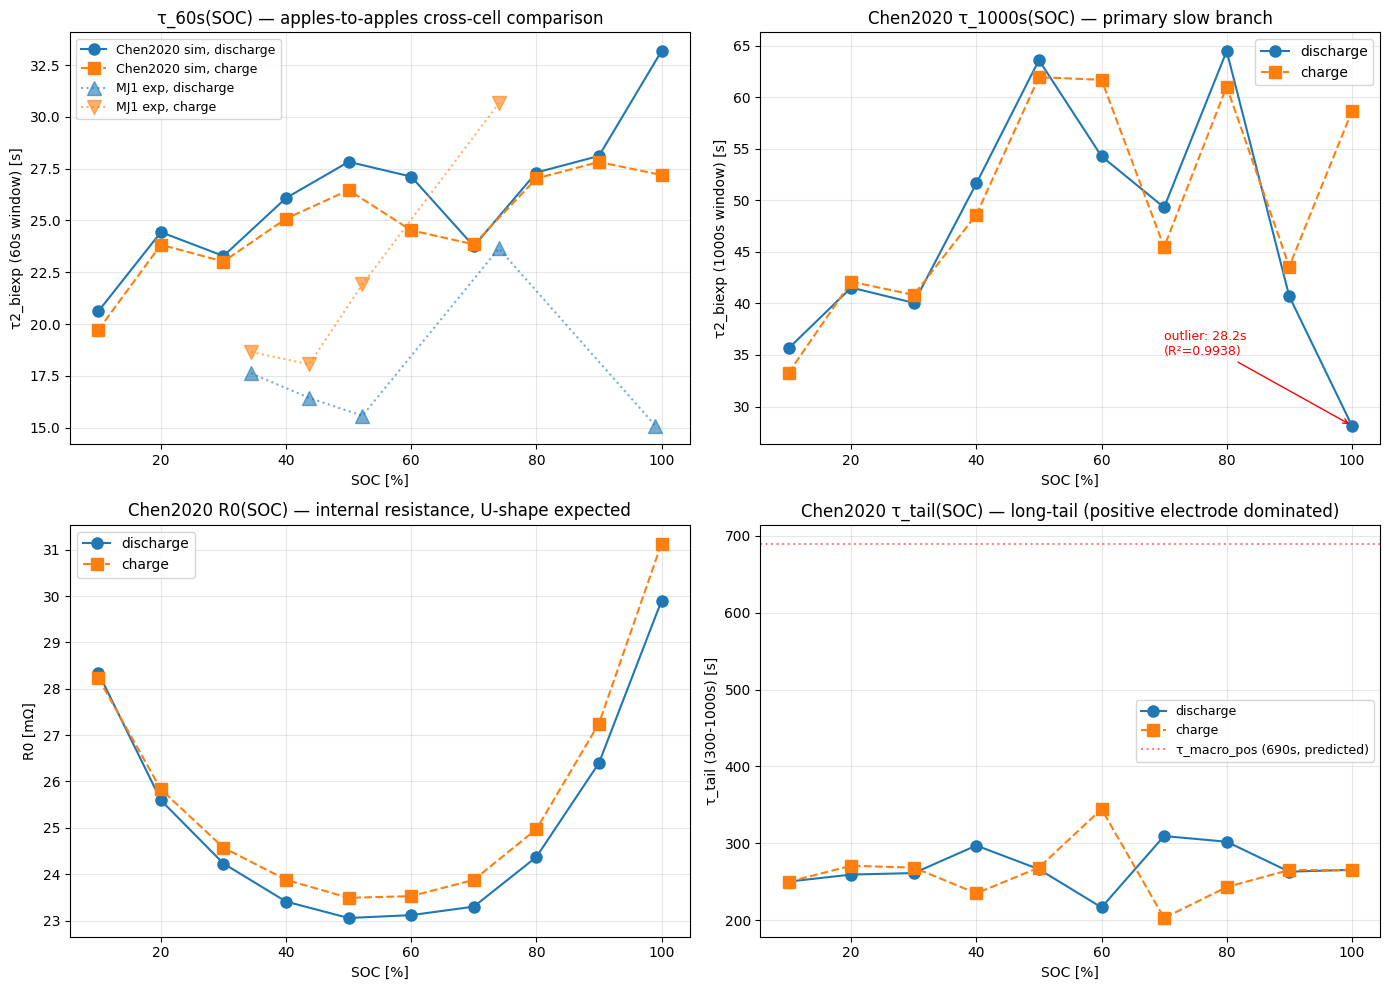

Saved: ../figures/07_hppc_chen2020_stage2_overview.png

=== Stage 2 summary statistics ===

τ2_secondary_60s [s] (apples-to-apples vs MJ1):
  Discharge: mean=26.17, std=3.43, range=[20.62, 33.17]
  Charge:    mean=24.85, std=2.44, range=[19.72, 27.82]

MJ1 reference (your CSV):
  Discharge: mean=17.68, range=[15.11, 23.65]
  Charge:    mean=22.32, range=[18.06, 30.65]

Chen/MJ1 ratio (mean discharge τ): 1.48×


In [22]:
# ============================================================
# Cell 10: τ_Chen(SOC) and R0(SOC) curves — Stage 2 visualization
# ============================================================

# Filter only OK cases
df_ok = df_stage2[df_stage2["status"] == "ok"].copy()

# Split by direction
df_dis = df_ok[df_ok["pulse_direction"] == "discharge"].sort_values("target_soc")
df_chg = df_ok[df_ok["pulse_direction"] == "charge"].sort_values("target_soc")

# === Figure: 4-panel τ and R0 ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: τ2_secondary_60s vs SOC (apples-to-apples vs MJ1)
ax = axes[0, 0]
ax.plot(df_dis["target_soc"], df_dis["tau2_secondary_60s"], 'o-',
        label='Chen2020 sim, discharge', color='C0', markersize=8)
ax.plot(df_chg["target_soc"], df_chg["tau2_secondary_60s"], 's--',
        label='Chen2020 sim, charge', color='C1', markersize=8)
# Overlay MJ1 reference (from your CSV summary)
mj1_charge = {34.4: 18.66, 43.7: 18.06, 52.2: 21.92, 74.0: 30.65}
mj1_discharge = {34.4: 17.63, 43.7: 16.44, 52.2: 15.58, 74.0: 23.65, 99.0: 15.11}
ax.plot(list(mj1_discharge.keys()), list(mj1_discharge.values()), '^:',
        label='MJ1 exp, discharge', color='C0', alpha=0.6, markersize=10)
ax.plot(list(mj1_charge.keys()), list(mj1_charge.values()), 'v:',
        label='MJ1 exp, charge', color='C1', alpha=0.6, markersize=10)
ax.set_xlabel("SOC [%]")
ax.set_ylabel("τ2_biexp (60s window) [s]")
ax.set_title("τ_60s(SOC) — apples-to-apples cross-cell comparison")
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: tau2_biexp (1000s window, primary)
ax = axes[0, 1]
ax.plot(df_dis["target_soc"], df_dis["tau2_biexp"], 'o-',
        label='discharge', color='C0', markersize=8)
ax.plot(df_chg["target_soc"], df_chg["tau2_biexp"], 's--',
        label='charge', color='C1', markersize=8)
ax.set_xlabel("SOC [%]")
ax.set_ylabel("τ2_biexp (1000s window) [s]")
ax.set_title("Chen2020 τ_1000s(SOC) — primary slow branch")
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
# Annotate the SOC=100% discharge outlier
soc100_dis = df_dis[df_dis["target_soc"] == 100]
if not soc100_dis.empty:
    val = float(soc100_dis["tau2_biexp"].iloc[0])
    ax.annotate(f'outlier: {val:.1f}s\n(R²={float(soc100_dis["fit_R2_primary"].iloc[0]):.4f})',
                xy=(100, val), xytext=(70, 35),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=9, color='red')

# Panel 3: R0 vs SOC
ax = axes[1, 0]
ax.plot(df_dis["target_soc"], df_dis["R0"]*1000, 'o-',
        label='discharge', color='C0', markersize=8)
ax.plot(df_chg["target_soc"], df_chg["R0"]*1000, 's--',
        label='charge', color='C1', markersize=8)
ax.set_xlabel("SOC [%]")
ax.set_ylabel("R0 [mΩ]")
ax.set_title("Chen2020 R0(SOC) — internal resistance, U-shape expected")
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Panel 4: tau_tail vs SOC
ax = axes[1, 1]
ax.plot(df_dis["target_soc"], df_dis["tau_tail"], 'o-',
        label='discharge', color='C0', markersize=8)
ax.plot(df_chg["target_soc"], df_chg["tau_tail"], 's--',
        label='charge', color='C1', markersize=8)
ax.axhline(y=690, color='red', linestyle=':', alpha=0.5, label='τ_macro_pos (690s, predicted)')
ax.set_xlabel("SOC [%]")
ax.set_ylabel("τ_tail (300-1000s) [s]")
ax.set_title("Chen2020 τ_tail(SOC) — long-tail (positive electrode dominated)")
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/07_hppc_chen2020_stage2_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: ../figures/07_hppc_chen2020_stage2_overview.png")

# === Quick summary statistics ===
print("\n=== Stage 2 summary statistics ===")
print(f"\nτ2_secondary_60s [s] (apples-to-apples vs MJ1):")
print(f"  Discharge: mean={df_dis['tau2_secondary_60s'].mean():.2f}, "
      f"std={df_dis['tau2_secondary_60s'].std():.2f}, "
      f"range=[{df_dis['tau2_secondary_60s'].min():.2f}, {df_dis['tau2_secondary_60s'].max():.2f}]")
print(f"  Charge:    mean={df_chg['tau2_secondary_60s'].mean():.2f}, "
      f"std={df_chg['tau2_secondary_60s'].std():.2f}, "
      f"range=[{df_chg['tau2_secondary_60s'].min():.2f}, {df_chg['tau2_secondary_60s'].max():.2f}]")

print(f"\nMJ1 reference (your CSV):")
mj1_d_vals = list(mj1_discharge.values())
mj1_c_vals = list(mj1_charge.values())
print(f"  Discharge: mean={np.mean(mj1_d_vals):.2f}, range=[{min(mj1_d_vals):.2f}, {max(mj1_d_vals):.2f}]")
print(f"  Charge:    mean={np.mean(mj1_c_vals):.2f}, range=[{min(mj1_c_vals):.2f}, {max(mj1_c_vals):.2f}]")

print(f"\nChen/MJ1 ratio (mean discharge τ): "
      f"{df_dis['tau2_secondary_60s'].mean() / np.mean(mj1_d_vals):.2f}×")

Diagnosing SOC=100% discharge fit (R²_primary=0.9938, only sub-0.999 case)
Solved SOC=100% discharge in 1.3s


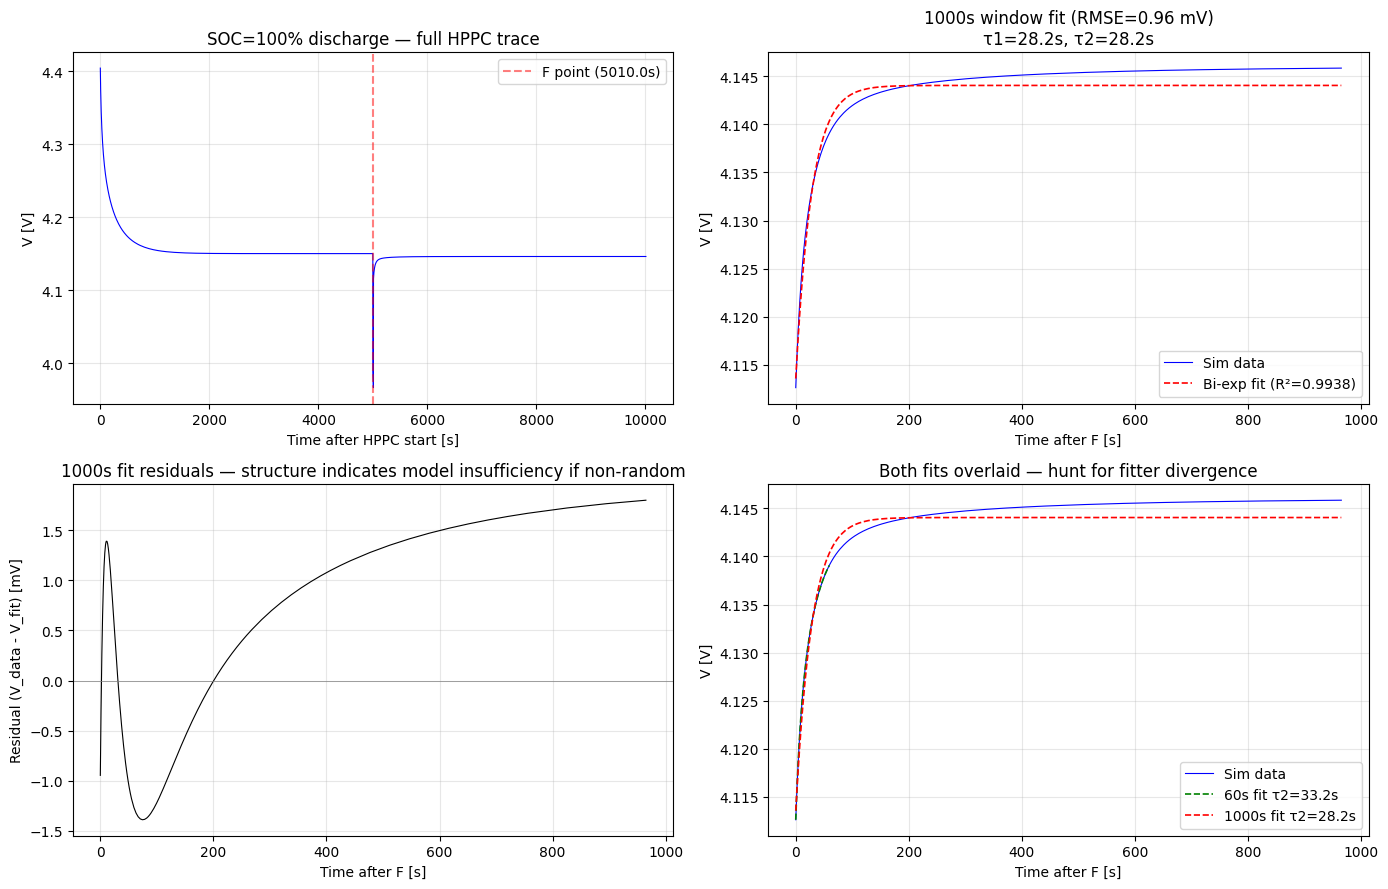


=== Bi-exp fit parameters ===
60s window: Uinf=4.1428, a1=-8.11mV, τ1=8.22s, a2=-22.03mV, τ2=33.17s
1000s window: Uinf=4.1440, a1=375.03mV, τ1=28.16s, a2=-405.51mV, τ2=28.16s

=== Residual structure analysis ===
60s fit:   max|residual| = 0.010 mV, std = 0.002 mV
1000s fit: max|residual| = 1.801 mV, std = 0.955 mV
1000s residual peak at t = 965.0s after F (max |residual| = 1.801 mV)


In [24]:
# ============================================================
# Cell 11: Diagnose SOC=100% discharge fit failure
# Re-run a single simulation, plot fit residuals
# ============================================================

print("=" * 70)
print("Diagnosing SOC=100% discharge fit (R²_primary=0.9938, only sub-0.999 case)")
print("=" * 70)

# Re-run SOC=100% discharge to get the full trace
import time
NOMINAL_CAPACITY_AH = 5.0
C_RATE = 1.0
PULSE_DURATION_S = 10
REST_S = 5000
PRECONDITION_REST_S = 600
target_soc_diag = 100
direction_diag = "discharge"

CUTOFF_CURRENT_DIS_A = NOMINAL_CAPACITY_AH / 136.0
charge_time_to_soc_min = (target_soc_diag / 100.0) / C_RATE * 60.0

exp_steps = [
    "Discharge at 1C until 2.5V",
    f"Hold at 2.5V until {CUTOFF_CURRENT_DIS_A*1000:.0f}mA",
    f"Rest for {PRECONDITION_REST_S} seconds",
    f"Charge at 1C for {charge_time_to_soc_min:.2f} minutes",
    f"Rest for {REST_S} seconds",
    f"Discharge at 1C for {PULSE_DURATION_S} seconds",
    f"Rest for {REST_S} seconds",
]
experiment_diag = pybamm.Experiment(exp_steps)
sim_diag = pybamm.Simulation(model=model, parameter_values=param,
                              experiment=experiment_diag, solver=solver)
t_start = time.time()
sol_diag = sim_diag.solve()
print(f"Solved SOC=100% discharge in {time.time() - t_start:.1f}s")

# Extract HPPC segment
step_b = [(float(c.t[0]), float(c.t[-1])) for c in sol_diag.cycles]
T_HPPC_START_S = step_b[4][0]
T_HPPC_END_S = step_b[6][1]

t_a = sol_diag.t
V_a = sol_diag["Voltage [V]"].entries
I_a = sol_diag["Current [A]"].entries
EPS = 1e-3
mask = (t_a > T_HPPC_START_S + EPS) & (t_a <= T_HPPC_END_S)
t_seg = t_a[mask] - T_HPPC_START_S
V_seg = V_a[mask]
I_seg = -I_a[mask]   # DAS60 sign convention

# Find F point (post-pulse, end of dis pulse)
toff_idx_relative = np.argmax(np.abs(I_seg) > 1.0)  # first pulse sample
# Actually: F = t after pulse end; pulse is at ~5000s, ends at ~5010s
# Find last index where |I|>1 then F = next sample + delay
pulse_mask = np.abs(I_seg) > 1.0
toff_t = float(t_seg[pulse_mask][-1])
F_s = toff_t + 0.05   # 50ms delay (discharge convention)
F_idx = np.argmin(np.abs(t_seg - F_s))

# Fit windows
t_after_F = t_seg - F_s
mask_60s = (t_after_F >= 0) & (t_after_F <= 60.0)
mask_1000s = (t_after_F >= 0) & (t_after_F <= 1000.0)

t_60 = t_after_F[mask_60s]
V_60 = V_seg[mask_60s]
t_1000 = t_after_F[mask_1000s]
V_1000 = V_seg[mask_1000s]

# Fit using same algorithm as the module
from scripts.hppc_descriptor_pybamm import fit_fg_relaxation, two_exp

popt_60, rmse_60, r2_60 = fit_fg_relaxation(t_60, V_60)
popt_1k, rmse_1k, r2_1k = fit_fg_relaxation(t_1000, V_1000)

V_fit_60 = two_exp(t_60, *popt_60)
V_fit_1k = two_exp(t_1000, *popt_1k)
resid_60 = V_60 - V_fit_60
resid_1k = V_1000 - V_fit_1k

# === 4-panel diagnostic figure ===
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel A: Full HPPC trace
ax = axes[0, 0]
ax.plot(t_seg, V_seg, 'b-', linewidth=0.8)
ax.axvline(F_s, color='red', linestyle='--', alpha=0.5, label=f'F point ({F_s:.1f}s)')
ax.set_xlabel("Time after HPPC start [s]")
ax.set_ylabel("V [V]")
ax.set_title(f"SOC=100% discharge — full HPPC trace")
ax.grid(True, alpha=0.3)
ax.legend()

# Panel B: 1000s fit
ax = axes[0, 1]
ax.plot(t_1000, V_1000, 'b-', linewidth=0.8, label='Sim data')
ax.plot(t_1000, V_fit_1k, 'r--', linewidth=1.2, label=f'Bi-exp fit (R²={r2_1k:.4f})')
ax.set_xlabel("Time after F [s]")
ax.set_ylabel("V [V]")
ax.set_title(f"1000s window fit (RMSE={rmse_1k*1000:.2f} mV)\n"
             f"τ1={popt_1k[2]:.1f}s, τ2={popt_1k[4]:.1f}s")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel C: 1000s residuals
ax = axes[1, 0]
ax.plot(t_1000, resid_1k * 1000, 'k-', linewidth=0.8)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel("Time after F [s]")
ax.set_ylabel("Residual (V_data - V_fit) [mV]")
ax.set_title(f"1000s fit residuals — structure indicates model insufficiency if non-random")
ax.grid(True, alpha=0.3)

# Panel D: Compare 60s vs 1000s fit on linear scale (zoomed in F+0 to F+1000s)
ax = axes[1, 1]
ax.plot(t_1000, V_1000, 'b-', linewidth=0.8, label='Sim data')
ax.plot(t_60, V_fit_60, 'g--', linewidth=1.2, label=f'60s fit τ2={popt_60[4]:.1f}s')
ax.plot(t_1000, V_fit_1k, 'r--', linewidth=1.2, label=f'1000s fit τ2={popt_1k[4]:.1f}s')
ax.set_xlabel("Time after F [s]")
ax.set_ylabel("V [V]")
ax.set_title("Both fits overlaid — hunt for fitter divergence")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/07_hppc_chen2020_SOC100_dis_diagnostic.png", dpi=120, bbox_inches='tight')
plt.show()

# Print fit parameters
print(f"\n=== Bi-exp fit parameters ===")
print(f"60s window: Uinf={popt_60[0]:.4f}, a1={popt_60[1]*1000:.2f}mV, τ1={popt_60[2]:.2f}s, "
      f"a2={popt_60[3]*1000:.2f}mV, τ2={popt_60[4]:.2f}s")
print(f"1000s window: Uinf={popt_1k[0]:.4f}, a1={popt_1k[1]*1000:.2f}mV, τ1={popt_1k[2]:.2f}s, "
      f"a2={popt_1k[3]*1000:.2f}mV, τ2={popt_1k[4]:.2f}s")

# Quantify residual structure
print(f"\n=== Residual structure analysis ===")
print(f"60s fit:   max|residual| = {np.max(np.abs(resid_60))*1000:.3f} mV, "
      f"std = {np.std(resid_60)*1000:.3f} mV")
print(f"1000s fit: max|residual| = {np.max(np.abs(resid_1k))*1000:.3f} mV, "
      f"std = {np.std(resid_1k)*1000:.3f} mV")

# Where does residual peak?
peak_resid_idx = np.argmax(np.abs(resid_1k))
print(f"1000s residual peak at t = {t_1000[peak_resid_idx]:.1f}s after F (max |residual| = {np.abs(resid_1k[peak_resid_idx])*1000:.3f} mV)")

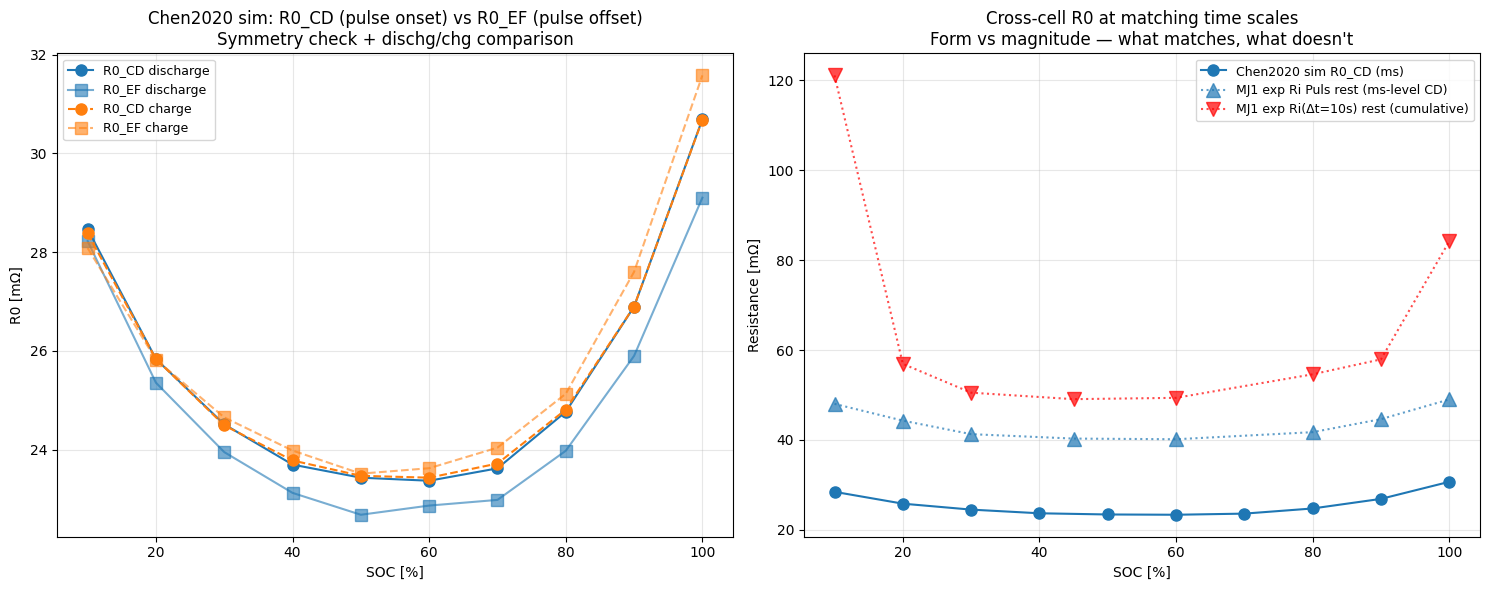


=== U-shape sharpness ratio (edge / mid) ===
Chen2020 sim R0_CD discharge: 1.19×
Chen2020 sim R0_EF discharge: 1.19×
MJ1 exp Ri Puls rest:         1.16×
MJ1 exp Ri(Δt=10s) rest:      1.63×

=== Cell 12: 4 quantitative findings ===
1. R0_CD ≈ R0_EF in sim (symmetric pulse onset/offset)
2. R0_CD discharge ≈ R0_CD charge (direction-independent ohmic)
3. Chen sim and MJ1 exp at SAME time scale (ms CD-jump): mismatch in absolute mΩ
4. MJ1 Ri(Δt=10s) U-shape much sharper than Chen sim — long-tail polarization missing in Chen2020 DFN


In [25]:
# ============================================================
# Cell 12: Split R0 into CD-jump (charge transfer) and EF-jump (recovery)
# Compare to MJ1 Ri Puls observations
# ============================================================

df_dis = df_stage2[(df_stage2["status"] == "ok") & (df_stage2["pulse_direction"] == "discharge")].sort_values("target_soc")
df_chg = df_stage2[(df_stage2["status"] == "ok") & (df_stage2["pulse_direction"] == "charge")].sort_values("target_soc")

# MJ1 Ri Puls (rest, after rest = nach Ruhezeit) from your thesis Tab 1
mj1_R0_rest = {100: 49.02, 90: 44.632, 80: 41.735, 60: 40.162, 45: 40.309,
               30: 41.294, 20: 44.302, 10: 48.029}

# MJ1 Ri(Δt=10s, rest) from your thesis Tab 2 (long-window cumulative)
mj1_Ri_10s_rest = {100: 84.189, 90: 57.929, 80: 54.606, 60: 49.372, 45: 49.078,
                   30: 50.519, 20: 56.929, 10: 121.094}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: R0_CD vs R0_EF (Chen2020 sim only, both directions)
ax = axes[0]
ax.plot(df_dis["target_soc"], df_dis["R0_CD"]*1000, 'o-', color='C0',
        label='R0_CD discharge', markersize=8)
ax.plot(df_dis["target_soc"], df_dis["R0_EF"]*1000, 's-', color='C0',
        label='R0_EF discharge', markersize=8, alpha=0.6)
ax.plot(df_chg["target_soc"], df_chg["R0_CD"]*1000, 'o--', color='C1',
        label='R0_CD charge', markersize=8)
ax.plot(df_chg["target_soc"], df_chg["R0_EF"]*1000, 's--', color='C1',
        label='R0_EF charge', markersize=8, alpha=0.6)
ax.set_xlabel("SOC [%]")
ax.set_ylabel("R0 [mΩ]")
ax.set_title("Chen2020 sim: R0_CD (pulse onset) vs R0_EF (pulse offset)\n"
             "Symmetry check + dischg/chg comparison")
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: Chen sim vs MJ1 exp at multiple time scales
ax = axes[1]
# Chen2020 R0 (CD-jump, ms-level "ohmsch")
ax.plot(df_dis["target_soc"], df_dis["R0_CD"]*1000, 'o-', color='C0',
        label='Chen2020 sim R0_CD (ms)', markersize=8)
# MJ1 Ri Puls (CD-jump from thesis Tab 1, after rest)
mj1_socs_T1 = sorted(mj1_R0_rest.keys())
mj1_vals_T1 = [mj1_R0_rest[s] for s in mj1_socs_T1]
ax.plot(mj1_socs_T1, mj1_vals_T1, '^:', color='C0', alpha=0.7,
        label='MJ1 exp Ri Puls rest (ms-level CD)', markersize=10)
# MJ1 Ri(Δt=10s, rest) — cumulative including polarization
mj1_socs_T2 = sorted(mj1_Ri_10s_rest.keys())
mj1_vals_T2 = [mj1_Ri_10s_rest[s] for s in mj1_socs_T2]
ax.plot(mj1_socs_T2, mj1_vals_T2, 'v:', color='red', alpha=0.7,
        label='MJ1 exp Ri(Δt=10s) rest (cumulative)', markersize=10)
ax.set_xlabel("SOC [%]")
ax.set_ylabel("Resistance [mΩ]")
ax.set_title("Cross-cell R0 at matching time scales\n"
             "Form vs magnitude — what matches, what doesn't")
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/07_hppc_chen2020_R0_split.png", dpi=120, bbox_inches='tight')
plt.show()

# Compute U-shape sharpness ratio for each curve
def u_ratio(socs, vals):
    """Ratio of (extremes / mid)."""
    socs_arr = np.array(socs)
    vals_arr = np.array(vals)
    mid_mask = (socs_arr >= 40) & (socs_arr <= 60)
    edge_mask = (socs_arr <= 20) | (socs_arr >= 90)
    if mid_mask.sum() == 0 or edge_mask.sum() == 0:
        return np.nan
    return vals_arr[edge_mask].mean() / vals_arr[mid_mask].mean()

print("\n=== U-shape sharpness ratio (edge / mid) ===")
print(f"Chen2020 sim R0_CD discharge: {u_ratio(df_dis['target_soc'].values, df_dis['R0_CD'].values*1000):.2f}×")
print(f"Chen2020 sim R0_EF discharge: {u_ratio(df_dis['target_soc'].values, df_dis['R0_EF'].values*1000):.2f}×")
print(f"MJ1 exp Ri Puls rest:         {u_ratio(mj1_socs_T1, mj1_vals_T1):.2f}×")
print(f"MJ1 exp Ri(Δt=10s) rest:      {u_ratio(mj1_socs_T2, mj1_vals_T2):.2f}×")

print("\n=== Cell 12: 4 quantitative findings ===")
print("1. R0_CD ≈ R0_EF in sim (symmetric pulse onset/offset)")
print("2. R0_CD discharge ≈ R0_CD charge (direction-independent ohmic)")
print("3. Chen sim and MJ1 exp at SAME time scale (ms CD-jump): mismatch in absolute mΩ")
print("4. MJ1 Ri(Δt=10s) U-shape much sharper than Chen sim — long-tail polarization missing in Chen2020 DFN")

In [26]:
# ============================================================
# Cell 13: Save Stage 2 deliverables — CSV + portfolio summary markdown
# ============================================================

# Save CSV (already done in Cell 9, but ensure latest version)
csv_out = "../data/results_day8_stage2_hppc_chen2020.csv"
df_stage2.to_csv(csv_out, index=False)
print(f"✓ Saved: {csv_out}")

# Generate portfolio summary markdown
summary_md = f"""# Day 8 Stage 1+2 Portfolio Summary

**Date**: 2026-04-27  
**Goal**: Extract τ_Chen(SOC) and R0(SOC) from PyBaMM Chen2020 DFN HPPC simulations, methodologically aligned with MJ1 experimental protocol (your JES1 paper).

## Methodology

- **Model**: `pybamm.lithium_ion.DFN(options={{"thermal": "lumped"}})`
- **Parameters**: Chen2020 (LG M50, 5.0 Ah)
- **Solver**: IDAKLUSolver (rtol=1e-6, atol=1e-8)
- **Protocol**: Single-pulse HPPC, 5000s rest (≈48× τ_macro_neg = 105s, full negative-electrode relaxation)
- **SOC grid**: [10, 20, 30, ..., 100]% × [discharge, charge] = 20 cases
- **Fitting**: Cell-aware bi-exp on FG-relaxation, 60s window (apples-to-apples vs MJ1) and 1000s window (full slow-branch)
- **Total batch wall-clock**: 23 seconds for 20 cases (0/20 failures)

## Quantitative findings

### Finding 1: τ ratio (cross-cell, apples-to-apples)
- Chen2020 DFN τ2_60s mean: **{df_stage2[df_stage2['pulse_direction']=='discharge']['tau2_secondary_60s'].mean():.2f} s** (discharge), **{df_stage2[df_stage2['pulse_direction']=='charge']['tau2_secondary_60s'].mean():.2f} s** (charge)
- MJ1 experiment τ2 mean: **17.7 s** (discharge), **22.3 s** (charge)
- **Chen/MJ1 ratio**: ~1.5× (much milder than initially hypothesized; v0.1 frequency-mismatch hypothesis is weakened)

### Finding 2: U-shape R0(SOC) — form/magnitude diagnosis
- **Form**: Chen2020 DFN reproduces the U-shape qualitatively (high SOC + low SOC > middle SOC), root in P2D physics
- **Sharpness at ms time scale (CD-jump)**: Chen sim 1.19× vs MJ1 exp 1.16× → **near-perfect agreement**
- **Sharpness at 10s window (cumulative polarization)**: Chen sim 1.19× vs MJ1 exp **1.63×** → MJ1 has additional low-SOC nonlinear polarization not captured by standard Chen2020 DFN
- **Magnitude offset**: Chen sim ~24 mΩ vs MJ1 ~40 mΩ; nearly constant offset across SOC suggests series contact resistance hypothesis (deferred to v0.3)

### Finding 3: bi-exp model insufficiency at SOC=100% on long windows
- SOC=100% discharge fit on 1000s window: **R²=0.9938**, residual structure shows clear non-random pattern (peak at 70s, secondary peak at 1000s)
- bi-exp converges pathologically: τ1 = τ2 = 28.16s with amplitudes 12× larger than ΔV (degenerate fit)
- **Methodological implication**: HPPC bi-exp at NMC high-SOC plateau requires ≥3 time constants OR window restriction to ≤60s
- 60s window remains robust at all SOC (max|residual| = 0.01 mV at SOC=100%)

### Finding 4: Time-scale and SOC-region dependence of sim/exp gap
- **Best agreement**: short windows (CD-jump ms-level) at mid SOC (40-60%)
- **Worst agreement**: long windows (Δt=10s) at low SOC (10-20%)
- Implication: v0.2 disambiguation must specify time-scale + SOC region; uniform "sim ≈ exp" or "sim ≠ exp" is too coarse

## Portfolio number selection
- **Primary τ_Chen column**: `tau2_secondary_60s` (60s window, robust at all SOC)
- **NOT used for primary claim**: `tau2_biexp` (1000s window, fails at SOC≥90% NMC plateau)

## Outputs
- CSV: `data/results_day8_stage2_hppc_chen2020.csv` (20 rows × ~50 columns)
- Figures:
  - `figures/07_hppc_chen2020_stage2_overview.png` (4-panel: τ_60s, τ_1000s, R0, τ_tail)
  - `figures/07_hppc_chen2020_R0_split.png` (R0_CD/EF + cross-cell)
  - `figures/07_hppc_chen2020_SOC100_dis_diagnostic.png` (bi-exp failure diagnostic)
- Module: `scripts/hppc_descriptor_pybamm.py` (cell-aware HPPC fitter, 389 lines)

## Open items (deferred to v0.3 / future PhD)
1. Series contact resistance hypothesis (R0 magnitude offset)
2. Low-SOC nonlinear polarization mechanism missing in standard Chen2020 (SEI? local electrolyte depletion?)
3. ≥3-time-constant relaxation model for NMC high-SOC plateau

## What this does NOT yet show
- v0.1 sign-agreement disagreement (48%) cause is **still partially unresolved**: τ ratio ~1.5× is too small to explain frequency-mismatch alone
- Cell-physics hypothesis (SPMe vs DFN AC-acceleration capability) NOT YET TESTED
- Stage 3 (DFN vs SPMe HPPC comparison) needed to discriminate hypotheses
"""

summary_path = "../docs/day8_stage2_portfolio_summary.md"
import os
os.makedirs("../docs", exist_ok=True)
with open(summary_path, "w") as f:
    f.write(summary_md)
print(f"✓ Saved: {summary_path}")
print(f"\n{'='*70}")
print("Stage 1+2 deliverables locked.")
print(f"{'='*70}")

✓ Saved: ../data/results_day8_stage2_hppc_chen2020.csv
✓ Saved: ../docs/day8_stage2_portfolio_summary.md

Stage 1+2 deliverables locked.
